# Linear Regression with Batch Gradient Descent

You will train your model using a real world dataset.  The dataset contains a collection of real estate listings in San Luis Obispo county.

The model predict the price given the square footage of the house.


## Complete this code

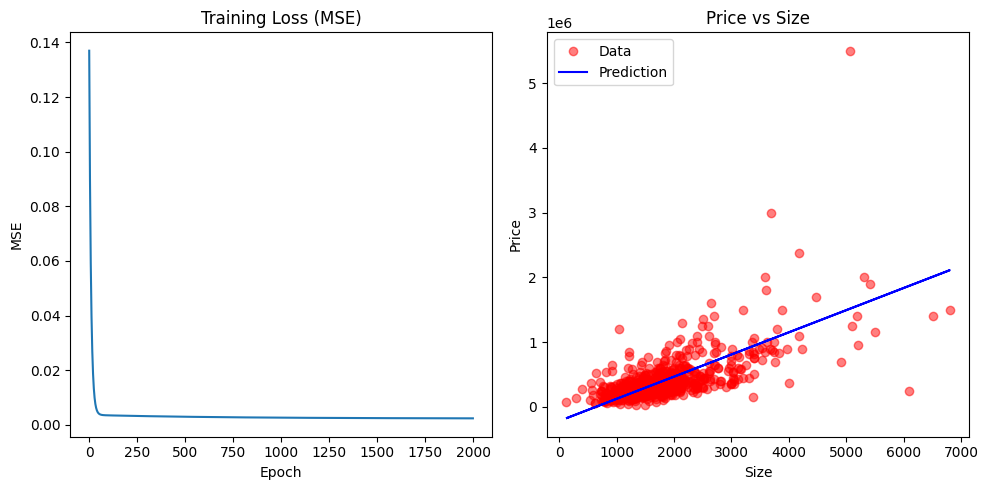

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Data Manager
class DataManager:
    def __init__(self, x_raw, y_raw):
        # Normalize
        self.x_min, self.x_range = np.min(x_raw), np.ptp(x_raw)
        self.y_min, self.y_range = np.min(y_raw), np.ptp(y_raw)
        self.x_range = self.x_range if self.x_range != 0 else 1.0
        self.y_range = self.y_range if self.y_range != 0 else 1.0
        X_norm = (x_raw - self.x_min) / self.x_range
        Y_norm = (y_raw - self.y_min) / self.y_range
        # Split: 10% Test, 10% Val, 80% Train
        X_rem, self.X_test, Y_rem, self.Y_test = train_test_split(
            X_norm, Y_norm, test_size=0.1, random_state=42
        )
        self.X_train, self.X_val, self.Y_train, self.Y_val = train_test_split(
            X_rem, Y_rem, test_size=0.1111, random_state=42
        )
        self.X_full = X_norm
        self.Y_full = Y_norm

    def denormalize_x(self, x_norm):
        return x_norm * self.x_range + self.x_min

    def denormalize_y(self, y_norm):
        return y_norm * self.y_range + self.y_min

# Model Core
class LinearRegressionGD:
    def __init__(self):
        # Weights: Bias, Slope ( y = mx + b )
        self.W = np.random.rand(2)
        self.losses = []

    def predict(self, X):
        return self.W[0] + self.W[1] * X

    def compute_loss(self, X, Y):
        predictions = self.predict(X)
        errors = predictions - Y
        mse = np.mean(errors ** 2)
        return mse, errors

    def step(self, X, Y, lr):
        m = len(X)
        mse, errors = self.compute_loss(X, Y)
        # Gradient Calculation
        grad_bias = np.sum(errors) / m
        grad_slope = np.sum(errors * X) / m
        # Update Weights
        self.W[0] -= lr * grad_bias
        self.W[1] -= lr * grad_slope
        return mse

# Model Trainer
class Trainer:
    def __init__(self, model, data):
        self.model = model
        self.data = data

    def train(self, epochs, lr, mode="train"):
        # Select data based on mode
        if mode == "full":
            X, Y = self.data.X_full, self.data.Y_full
        else:
            X, Y = self.data.X_train, self.data.Y_train
            
        loss_history = []
        for epoch in range(epochs):
            mse = self.model.step(X, Y, lr)
            loss_history.append(mse)
            
        self.model.losses = loss_history
        return loss_history[-1] # Final MSE

    def evaluate(self, X, Y):
        mse, _ = self.model.compute_loss(X, Y)
        return mse

# Learning Rate Finder
class LearningRateFinder:
    def __init__(self, data, rates=[0.5, 0.1, 0.05, 0.01]):
        self.data = data
        self.rates = rates
        self.best_lr = rates[0]
        
    def find_best(self):
        best_val_loss = float('inf')
        for lr in self.rates:
            # Train a model for each LR
            model = LinearRegressionGD()
            trainer = Trainer(model, self.data)
            # Train on training set
            trainer.train(epochs=500, lr=lr, mode="train")
            # Validate on validation set
            val_loss = trainer.evaluate(self.data.X_val, self.data.Y_val)
            if val_loss < best_val_loss and not np.isnan(val_loss):
                best_val_loss = val_loss
                self.best_lr = lr
        return self.best_lr

# Visualizer
class Visualizer:
    def __init__(self, model, data, x_key, y_key):
        self.model = model
        self.data = data
        self.x_key = x_key
        self.y_key = y_key

    def plot_results(self):
        plt.figure(figsize=(10, 5))
        # Plot Loss Curve
        plt.subplot(1, 2, 1)
        plt.plot(self.model.losses)
        plt.title("Training Loss (MSE)")
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        # Plot Regression Line
        plt.subplot(1, 2, 2)
        # Get predictions for full dataset
        raw_x = self.data.denormalize_x(self.data.X_full)
        raw_y = self.data.denormalize_y(self.data.Y_full)
        # Predict (normalized) then denormalize for plotting
        pred_y_norm = self.model.predict(self.data.X_full)
        pred_y = self.data.denormalize_y(pred_y_norm)
        plt.plot(raw_x, raw_y, 'ro', alpha=0.5, label='Data')
        plt.plot(raw_x, pred_y, 'b-', label='Prediction')
        plt.title(f"{self.y_key} vs {self.x_key}")
        plt.xlabel(self.x_key)
        plt.ylabel(self.y_key)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Pipeline
class Pipeline:
    def __init__(self, csv_path, x_key, y_key):
        # Load Data
        df = pd.read_csv(csv_path)
        self.data = DataManager(df[x_key].values, df[y_key].values)
        self.x_key = x_key
        self.y_key = y_key
        
    def run(self):
        # Find Best Learning Rate
        finder = LearningRateFinder(self.data)
        best_lr = finder.find_best()
        # Train
        self.model = LinearRegressionGD()
        trainer = Trainer(self.model, self.data)
        mse = trainer.train(epochs=2000, lr=best_lr, mode="full")
        # Visualize
        self.visualizer = Visualizer(self.model, self.data, self.x_key, self.y_key)
        self.visualizer.plot_results()

if __name__ == "__main__":
    app = Pipeline("housing_price_data.csv", "Size", "Price")
    app.run()